En iyi parametreler: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Accuracy  : 0.965
Precision : 1.000
Recall    : 0.905
F1        : 0.950
ROC AUC   : 0.974

Classification report:
               precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



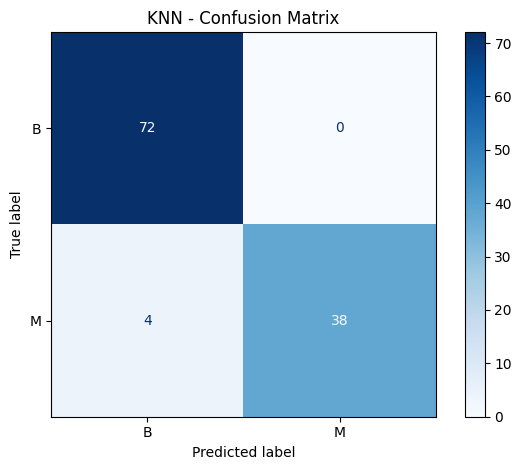

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)

# 1) Veri
df = pd.read_csv("bcwdata.csv")

# Bazı sürümlerde 'id' ve/veya 'Unnamed: 32' gelebiliyor; varsa atalım
drop_cols = [c for c in ["id", "ID", "Unnamed: 32"] if c in df.columns]
df = df.drop(columns=drop_cols)

# 2) X, y
# diagnosis: B (benign) / M (malignant).  M=1, B=0 olarak map'leyelim.
y = df["diagnosis"].map({"B": 0, "M": 1}).astype(int)
X = df.drop(columns=["diagnosis"])

# 3) Train/Test (stratify önemli)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4) Pipeline (ölçekleme + KNN)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# 5) Hiperparametre araması
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]  # 1: Manhattan, 2: Euclidean
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",         # istersen 'roc_auc' da deneyebilirsin
    cv=cv,
    n_jobs=-1,
    refit=True
)
gs.fit(X_train, y_train)

print("En iyi parametreler:", gs.best_params_)

# 6) Test performansı
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {acc:.3f}")
print(f"Precision : {prec:.3f}")
print(f"Recall    : {rec:.3f}")
print(f"F1        : {f1:.3f}")
print(f"ROC AUC   : {auc:.3f}")

print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["B","M"]))

# 7) Confusion matrix (isteğe bağlı görselleştirme)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["B","M"])
disp.plot(cmap="Blues", values_format="d")
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()
